# Île-de-France Metro Route Planner

**Authors:** _<your names here>_ — Bachelor in AI, PSL

Given two metro stations, return the shortest itinerary. This notebook builds the planner
directly from the **IDFM GTFS feed** (`stops.txt`, `routes.txt`, `stop_times.txt`,
`transfers.txt`) plus the IDFM *arrêts-par-ligne* export for line membership.

The code is hand-rolled on plain Python data structures. We use `pandas` only to read the
CSV/GTFS files and `matplotlib` only to draw maps — never a graph or shortest-path library.

The notebook is organised to mirror the **module architecture** from the project plan:

| Plan module | Where it lives here |
|---|---|
| `parser/`  | Part 2 — reads GTFS, produces clean tables |
| `graph/`   | Part 3 — turns tables into the route-space graph |
| `solver/`  | Part 1 — `dijkstra` / `a_star`, one `plan(...)` API |
| `viz/`     | Part 4.3 — `plot_itinerary` |
| `cli`      | `plan(graph, src, tgt)` glues it together |

## Mapping to the project plan

Because an earlier version only had the small *arrêts-lignes* file (no timetable, no stop
order), a few plan points were approximated. With the **full GTFS feed** they are now done
properly. This table is the honest status of every plan item.

| Plan item | Status |
|---|---|
| One node per `(station, line)` pair | ✅ done (Part 1.1, Part 3) |
| Riding edge weight = **mean travel time** from `stop_times.txt` | ✅ now real (Part 2.2). *Previously distance/speed.* |
| Real **stop order** from `stop_times.txt` | ✅ now real (Part 2.2). *Previously reconstructed with an MST.* |
| Transfer edges between `(station, line)` nodes | ✅ done (Part 3) |
| Transfer time | ✅ **data-driven from per-platform coordinates** (Part 3), validated against the official `transfers.txt` (Part 3.2) |
| Boarding/alighting hubs, query hub→hub | ✅ done, but **at query time only** (Part 4) — see the note below |
| Dijkstra (binary heap) + A* (admissible heuristic) | ✅ hand-written (Part 1) |
| Single `shortest_path` API, swappable solvers | ✅ `plan(..., algorithm=...)` (Part 4) |
| BFS to check one connected component | ✅ Part 3.1 |
| MST as a sanity-check skeleton figure | ✅ Part 6 |
| Topological sort / time-expanded graph | ✅ discussed (Part 6.3) |
| Experiment: transfer cost vs route chosen | ✅ Part 5.1 |
| Experiment: best `max_speed` for the heuristic | ✅ Part 5.2 (tied to the measured peak speed) |
| Experiment: when A* beats Dijkstra vs distance | ✅ Part 5.3 |

**The one deliberate change.** The plan attaches a permanent zero-cost hub to every
station. We attach hubs **only at query time** instead. A *permanent* hub would let the
search pass `(line A) → hub(0) → (line B)` and change lines for free, cancelling the
transfer penalties the plan itself defines. Query-time hubs touch only the endpoints, so
every line change in the middle still pays a transfer edge. This is explained in Part 4.

**A parser note.** This particular feed has no `trips.txt`, so a trip cannot be linked to
its route through the usual GTFS path. We use the IDFM *arrêts-par-ligne* export, which
lists the metro `(line, stop)` membership with per-platform coordinates, and join it to
`stop_times.txt` on `stop_id` (each metro platform belongs to exactly one line).

## Part 1 — Solver MVP on a tiny graph

Following the review, we get Dijkstra and A\* returning a correct path on a graph small
enough to check by hand, *before* touching any data.

### 1.1 Graph model

The central decision is **one node per `(station, line)` pair**, not per station. Châtelet
(lines 1, 4, 7, 11, 14) becomes five nodes. Two kinds of edges:

* **Riding edges** — between consecutive `(station, line)` nodes on a line; weight = travel
  time between those stops.
* **Transfer edges** — between two `(station, line)` nodes at the same station; weight =
  the time to change lines there.

This makes the transfer cost a property of the graph, so the solver stays a plain
shortest-path routine. The tiny network below already uses this representation.

In [1]:
def add_undirected(adj, u, v, weight):
    """Add an undirected edge u—v with the given weight to adjacency dict `adj`."""
    adj.setdefault(u, []).append((v, weight))
    adj.setdefault(v, []).append((u, weight))


# A tiny two-line network, small enough to verify by hand.
#
#   Line A :  Gare du Nord --4-- Châtelet --2-- Saint-Michel
#   Line B :  Louvre --3-- Châtelet --3-- Marais
#   Transfer at Châtelet between line A and line B : 5 min
#
# Nodes are (station, line) pairs, exactly as the real graph will use.
tiny_graph = {}
add_undirected(tiny_graph, ("Gare du Nord", "A"), ("Châtelet", "A"), 4)
add_undirected(tiny_graph, ("Châtelet", "A"),     ("Saint-Michel", "A"), 2)
add_undirected(tiny_graph, ("Louvre", "B"),       ("Châtelet", "B"), 3)
add_undirected(tiny_graph, ("Châtelet", "B"),     ("Marais", "B"), 3)
add_undirected(tiny_graph, ("Châtelet", "A"),     ("Châtelet", "B"), 5)   # transfer

# Abstract coordinates (1 unit ~ 1 minute) used only for the A* heuristic demo below.
TINY_COORDS = {
    "Gare du Nord": (2.0, 5.0),
    "Châtelet":     (2.0, 2.0),
    "Saint-Michel": (2.0, 0.0),
    "Louvre":       (0.0, 2.0),
    "Marais":       (4.0, 2.0),
}

for node, edges in tiny_graph.items():
    print(node, "->", edges)

('Gare du Nord', 'A') -> [(('Châtelet', 'A'), 4)]
('Châtelet', 'A') -> [(('Gare du Nord', 'A'), 4), (('Saint-Michel', 'A'), 2), (('Châtelet', 'B'), 5)]
('Saint-Michel', 'A') -> [(('Châtelet', 'A'), 2)]
('Louvre', 'B') -> [(('Châtelet', 'B'), 3)]
('Châtelet', 'B') -> [(('Louvre', 'B'), 3), (('Marais', 'B'), 3), (('Châtelet', 'A'), 5)]
('Marais', 'B') -> [(('Châtelet', 'B'), 3)]


### 1.2 Dijkstra

Dijkstra computes shortest paths from a source on a graph with **non-negative** weights. We
keep a min-heap of `(cost, node)` and a set of *finalized* nodes.

**Priority-queue invariant:** the first time a node is popped from the heap, the cost
recorded for it is already optimal. This holds because every weight is `>= 0`, so no path
found later can reach that node more cheaply. That is why we may stop as soon as we pop the
target, and why a node popped a second time (a stale heap entry) is skipped.

The integer `counter` in the heap tuples is just a tie-breaker, so two equal-cost entries
are ordered by insertion and the node objects are never compared. With a binary heap the
complexity is `O((V + E) log V)`.

In [2]:
import heapq
from itertools import count


def dijkstra(graph, source, target):
    """Shortest path from `source` to `target`.

    `graph` is a dict: node -> list of (neighbour, weight).
    Returns (path, cost, nodes_expanded).
    """
    dist = {source: 0.0}
    parent = {source: None}
    counter = count()                       # tie-breaker, so nodes are never compared
    pq = [(0.0, next(counter), source)]
    finalized = set()
    nodes_expanded = 0

    while pq:
        d, _, u = heapq.heappop(pq)
        if u in finalized:                  # stale entry: u is already settled
            continue
        finalized.add(u)
        nodes_expanded += 1
        if u == target:                     # invariant: dist[target] is now optimal
            break
        for v, w in graph.get(u, []):
            nd = d + w
            if nd < dist.get(v, float("inf")):
                dist[v] = nd
                parent[v] = u
                heapq.heappush(pq, (nd, next(counter), v))

    if target not in dist:
        return [], float("inf"), nodes_expanded

    path = []
    node = target
    while node is not None:
        path.append(node)
        node = parent[node]
    path.reverse()
    return path, dist[target], nodes_expanded

### 1.3 A\*

A\* orders the queue by `f(n) = g(n) + h(n)`, where `g(n)` is the best known cost from the
source and `h(n)` estimates the remaining cost to the target. Dijkstra is the case `h = 0`.

* **Admissible** — `h` never *overestimates* the true remaining cost. This guarantees A\*
  returns an optimal path.
* **Consistent (monotone)** — `h(u) <= w(u, v) + h(v)` for every edge. Consistency implies
  admissibility and guarantees a finalized node is never re-expanded (so the closed-set
  version below is correct).

**Our heuristic** is the straight-line distance to the target divided by a speed:
`h(n) = great_circle_km(n, target) / max_speed * 60` minutes. The true remaining cost is a
sequence of riding/transfer edges whose total length is at least the straight-line distance
(triangle inequality), so the true time is at least `great_circle / V_peak`, where `V_peak`
is the fastest effective speed any segment reaches. Hence `h` is a valid lower bound
**iff `max_speed >= V_peak`**. We *measure* `V_peak` from the real timetable in Part 5.2
(it turns out to be about 54 km/h), and use `max_speed = 60` by default.

In [3]:
import math


def great_circle_km(lon1, lat1, lon2, lat2):
    """Great-circle (haversine) distance between two (lon, lat) points, in km."""
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlmb = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlmb / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))


def a_star(graph, start, goal, heuristic):
    """A* shortest path. `heuristic(node)` estimates remaining cost to `goal`.

    Returns (path, cost, nodes_expanded). With an admissible heuristic the cost is optimal;
    with a consistent heuristic the closed-set below never needs re-expansion.
    """
    g = {start: 0.0}
    parent = {start: None}
    counter = count()
    pq = [(heuristic(start), next(counter), start)]
    finalized = set()
    nodes_expanded = 0

    while pq:
        _, _, u = heapq.heappop(pq)
        if u in finalized:
            continue
        finalized.add(u)
        nodes_expanded += 1
        if u == goal:
            break
        for v, w in graph.get(u, []):
            ng = g[u] + w
            if ng < g.get(v, float("inf")):
                g[v] = ng
                parent[v] = u
                heapq.heappush(pq, (ng + heuristic(v), next(counter), v))

    if goal not in g:
        return [], float("inf"), nodes_expanded

    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = parent[node]
    path.reverse()
    return path, g[goal], nodes_expanded

In [4]:
def tiny_heuristic(goal):
    """Straight-line distance to `goal` on the toy coordinates (1 unit ~ 1 min)."""
    gx, gy = TINY_COORDS[goal[0]]

    def h(node):
        x, y = TINY_COORDS[node[0]]
        return math.hypot(x - gx, y - gy)

    return h


# Saint-Michel (A) -> Louvre (B): only route is
# Saint-Michel --2--> Châtelet --5(transfer)--> Châtelet --3--> Louvre = 10 min.
start, goal = ("Saint-Michel", "A"), ("Louvre", "B")
d_path, d_cost, d_exp = dijkstra(tiny_graph, start, goal)
a_path, a_cost, a_exp = a_star(tiny_graph, start, goal, tiny_heuristic(goal))

print("Dijkstra :", d_cost, "min  |", d_path)
print("A*       :", a_cost, "min  |", a_path)
assert d_cost == a_cost == 10, "Dijkstra and A* must agree on the optimum (10 min)"
print("\nBoth agree on the optimum (10 min). The MVP works.")

Dijkstra : 10.0 min  | [('Saint-Michel', 'A'), ('Châtelet', 'A'), ('Châtelet', 'B'), ('Louvre', 'B')]
A*       : 10.0 min  | [('Saint-Michel', 'A'), ('Châtelet', 'A'), ('Châtelet', 'B'), ('Louvre', 'B')]

Both agree on the optimum (10 min). The MVP works.


## Part 2 — Parser: from GTFS to clean tables

The parser reads the raw feed and produces three clean objects, which is all the graph
layer needs:

* `node_coords` — one `(lon, lat)` per `(station, line)` node (its platform position);
* `riding` — mean travel time between adjacent `(station, line)` nodes;
* `official_transfer` — official transfer times from `transfers.txt`, for validation.

We use four GTFS files (`routes.txt`, `stops.txt`, `stop_times.txt`, `transfers.txt`) plus
the IDFM *arrêts-par-ligne* export for line membership (see the parser note at the top).

In [5]:
import os
import zipfile
import pandas as pd
from collections import defaultdict, deque

ARRETS_CSV = "arrets-lignes.csv"     # IDFM "arrêts par ligne" export (line membership)
GTFS_ZIP   = "IDFM-gtfs.zip"         # full IDFM GTFS feed
GTFS_DIR   = "gtfs"                  # where the feed is unzipped

# Unzip the GTFS feed once, if needed.
if not os.path.exists(os.path.join(GTFS_DIR, "stop_times.txt")):
    with zipfile.ZipFile(GTFS_ZIP) as z:
        z.extractall(GTFS_DIR)

# Metro lines = routes with route_type == 1.
routes = pd.read_csv(os.path.join(GTFS_DIR, "routes.txt"), dtype=str)
metro_routes = routes[routes["route_type"] == "1"]
print("Metro lines (route_type == 1):", len(metro_routes))
print("Line names:", sorted(metro_routes["route_short_name"]))

Metro lines (route_type == 1): 16
Line names: ['1', '10', '11', '12', '13', '14', '2', '3', '3B', '4', '5', '6', '7', '7B', '8', '9']


### 2.1 Line membership & per-platform coordinates

From the *arrêts-par-ligne* export we keep the metro rows and build:

* `stop_to_node` — `stop_id -> (station, line)`;
* `node_coords` — `(station, line) -> (lon, lat)`, averaging the (usually two, one per
  direction) platforms of that line at that station;
* `station_coords` — one averaged point per physical station (for the heuristic and maps);
* `line_to_stations` — the stations of each line (for the MST skeleton in Part 6).

The key fact your inspection revealed: **each line records its own platform position**, so
the `(station, line)` nodes at one station have *different* coordinates. That is what lets
us turn transfers into a distance in Part 3.

In [6]:
al = pd.read_csv(ARRETS_CSV, sep=";", encoding="utf-8-sig", dtype=str)
alm = al[al["mode"] == "Metro"].copy()
alm["lon"] = alm["stop_lon"].astype(float)
alm["lat"] = alm["stop_lat"].astype(float)

# stop_id -> (station, line). Each metro platform belongs to exactly one line.
stop_to_node = {r.stop_id: (r.stop_name, r.route_long_name) for r in alm.itertuples()}

# (station, line) -> averaged platform coordinates.
_node = alm.groupby(["route_long_name", "stop_name"]).agg(lon=("lon", "mean"), lat=("lat", "mean"))
node_coords = {(station, line): (row.lon, row.lat) for (line, station), row in _node.iterrows()}

# One averaged point per physical station.
_stn = alm.groupby("stop_name").agg(lon=("lon", "mean"), lat=("lat", "mean"))
station_coords = {name: (row.lon, row.lat) for name, row in _stn.iterrows()}

# Stations of each line (for the MST skeleton later).
line_to_stations = {}
for line, grp in alm.groupby("route_long_name"):
    seen = {}
    for r in grp.itertuples():
        seen[r.stop_name] = (r.lon, r.lat)
    line_to_stations[line] = [(n, lo, la) for n, (lo, la) in seen.items()]

print("(station, line) nodes :", len(node_coords))
print("Physical stations     :", len(station_coords))
print("\nChâtelet platforms have different coordinates per line:")
for (station, line), (lo, la) in sorted(node_coords.items()):
    if station == "Châtelet":
        print("  line %-3s : lon %.5f  lat %.5f" % (line, lo, la))

(station, line) nodes : 405
Physical stations     : 321

Châtelet platforms have different coordinates per line:
  line 1   : lon 2.34790  lat 48.85860
  line 11  : lon 2.34780  lat 48.85772
  line 14  : lon 2.34634  lat 48.85954
  line 4   : lon 2.34670  lat 48.85969
  line 7   : lon 2.34813  lat 48.85691


### 2.2 Real travel times from `stop_times.txt`

`stop_times.txt` is ~800 MB, so we read it in **chunks** and keep only rows whose `stop_id`
is a metro platform (this also discards every other mode automatically). Within each trip
we take consecutive stops (ordered by `stop_sequence`) and define the edge weight as the
mean, over all trips, of the **departure-to-departure** time:

`weight(i -> i+1) = mean( departure[i+1] - departure[i] )`.

Using departure-to-departure (rather than arrival-minus-departure) folds in the short
**dwell** at each station, so summing weights along a route gives a realistic in-vehicle
time. GTFS times can exceed `24:00:00` for after-midnight service, so we parse them as
plain seconds.

**One data-cleaning step.** A handful of trips (depot moves and partial runs) list
*non-adjacent* stations as consecutive, which would create false "express" edges letting
the planner skip stations. Real metro trains stop everywhere, so we keep a `(A, B)`
adjacency only if it appears in a substantial share of its line's trips — at least 20% of
that line's busiest segment. The genuine hops occur in ~4000 trips; the artifacts in ~80,
so the cut is clean (it removes ~8% of candidate edges and leaves each line a proper path).

In [7]:
# Read the big stop_times file in chunks, keeping only metro platforms.
metro_ids = set(stop_to_node)
cols = ["trip_id", "departure_time", "stop_id", "stop_sequence"]
kept = []
for chunk in pd.read_csv(os.path.join(GTFS_DIR, "stop_times.txt"),
                         usecols=cols, dtype=str, chunksize=1_000_000):
    kept.append(chunk[chunk["stop_id"].isin(metro_ids)])
stop_times = pd.concat(kept, ignore_index=True)


def to_seconds(hms):
    """Parse a GTFS HH:MM:SS time (possibly >= 24h) into seconds."""
    h, m, s = hms.split(":")
    return int(h) * 3600 + int(m) * 60 + int(s)


stop_times["dep"] = stop_times["departure_time"].map(to_seconds)
stop_times["seq"] = stop_times["stop_sequence"].astype(int)
stop_times = stop_times.sort_values(["trip_id", "seq"])

# Build riding edges: mean departure-to-departure time between adjacent (station, line) nodes.
_segments = defaultdict(list)
prev = None
for r in stop_times.itertuples():
    if prev is not None and prev.trip_id == r.trip_id and r.seq == prev.seq + 1:
        a, b = stop_to_node.get(prev.stop_id), stop_to_node.get(r.stop_id)
        if a and b and a != b:
            minutes = (r.dep - prev.dep) / 60.0
            if 0.05 <= minutes <= 15.0:        # drop bad/garbage timings
                _segments[frozenset((a, b))].append(minutes)
    prev = r

# Drop false "express" adjacencies (depot/partial runs): keep a segment only if it occurs
# in at least 20% of its line's busiest segment count.
seg_count = {pair: len(v) for pair, v in _segments.items()}
line_max = defaultdict(int)
for pair, c in seg_count.items():
    line = next(iter(pair))[1]                 # both endpoints share the line
    line_max[line] = max(line_max[line], c)

KEEP_FRACTION = 0.20
riding = {pair: sum(v) / len(v)
          for pair, v in _segments.items()
          if seg_count[pair] >= KEEP_FRACTION * line_max[next(iter(pair))[1]]}

print("Metro stop_times rows kept :", len(stop_times))
print("Candidate adjacencies      :", len(_segments))
print("Riding edges (after filter):", len(riding))
print("Mean hop time              : %.2f min" % (sum(riding.values()) / len(riding)))
print("\nA few line-1 hop times:")
shown = 0
for pair, t in riding.items():
    a, b = tuple(pair)
    if a[1] == "1" and b[1] == "1" and shown < 5:
        print("  %-26s <-> %-26s : %.2f min" % (a[0], b[0], t))
        shown += 1

Metro stop_times rows kept : 1100991
Candidate adjacencies      : 427
Riding edges (after filter): 391
Mean hop time              : 1.46 min

A few line-1 hop times:
  Bastille                   <-> Gare de Lyon               : 2.29 min
  Bastille                   <-> Saint-Paul (Le Marais)     : 2.05 min
  Hôtel de Ville             <-> Saint-Paul (Le Marais)     : 1.40 min
  Châtelet                   <-> Hôtel de Ville             : 1.32 min
  Louvre - Rivoli            <-> Châtelet                   : 1.25 min


### 2.3 Transfers

Two `(station, line)` nodes at the same station have different platform coordinates, so we
can compute a **data-driven transfer time** directly:
`great_circle(platform_a, platform_b) / walking_speed`. This is built in Part 3.

`transfers.txt` also gives **official** minimum transfer times. We load them here so we can
check our coordinate-based estimate against the official numbers in Part 3.2.

In [8]:
transfers = pd.read_csv(os.path.join(GTFS_DIR, "transfers.txt"), dtype=str)

# Keep transfers between two metro platforms at the SAME station on DIFFERENT lines.
official_transfer = {}    # (station, frozenset(line_a, line_b)) -> minutes
for r in transfers.itertuples():
    a, b = stop_to_node.get(r.from_stop_id), stop_to_node.get(r.to_stop_id)
    if a and b and a[0] == b[0] and a[1] != b[1]:
        if r.min_transfer_time and str(r.min_transfer_time) != "nan":
            minutes = float(r.min_transfer_time) / 60.0
            key = (a[0], frozenset((a[1], b[1])))
            official_transfer[key] = min(official_transfer.get(key, float("inf")), minutes)

print("Official metro transfer pairs loaded:", len(official_transfer))

Official metro transfer pairs loaded: 116


## Part 3 — Graph: assembling the route-space graph

We now turn the parser's tables into the `(station, line)` graph:

* **Riding edges** come straight from `riding` (real mean travel times).
* **Transfer edges** join the `(station, line)` nodes of each station, weighted by
  `great_circle(platform_a, platform_b) / walking_speed` — the data-driven transfer time.

No permanent hub is created (that would make transfers free); boarding/alighting hubs are
added only at query time in Part 4.

In [9]:
# --- Model parameters ---
WALKING_SPEED_KMH     =  5.0    # in-station walking speed, for transfer times
DEFAULT_MAX_SPEED_KMH = 60.0    # heuristic speed; >= the measured peak (~54 km/h, Part 5.2)


def km_to_minutes(km, speed_kmh):
    """Convert a distance to a travel time in minutes at the given speed."""
    return km / speed_kmh * 60.0


def transfer_minutes(node_a, node_b, node_coords, walking_speed):
    """Walking time between two platforms at the same station."""
    lon1, lat1 = node_coords[node_a]
    lon2, lat2 = node_coords[node_b]
    return km_to_minutes(great_circle_km(lon1, lat1, lon2, lat2), walking_speed)


def build_metro_graph(riding, node_coords, walking_speed=WALKING_SPEED_KMH):
    """Assemble the (station, line) graph.

    Riding edges  : the real mean travel times in `riding`.
    Transfer edges: platform-to-platform walk time at each interchange.
    Returns (graph, n_riding_edges, n_transfer_edges).
    """
    graph = {}

    n_riding = 0
    for pair, minutes in riding.items():
        a, b = tuple(pair)
        add_undirected(graph, a, b, minutes)
        n_riding += 1

    lines_at = defaultdict(set)
    for (station, line) in node_coords:
        lines_at[station].add(line)

    n_transfer = 0
    for station, lines in lines_at.items():
        lines = sorted(lines)
        for i in range(len(lines)):
            for j in range(i + 1, len(lines)):
                na, nb = (station, lines[i]), (station, lines[j])
                if na in node_coords and nb in node_coords:
                    add_undirected(graph, na, nb,
                                   transfer_minutes(na, nb, node_coords, walking_speed))
                    n_transfer += 1

    return graph, n_riding, n_transfer


metro_graph, n_riding, n_transfer = build_metro_graph(riding, node_coords)

print("Nodes          :", len(metro_graph))
print("Riding edges   :", n_riding)
print("Transfer edges :", n_transfer)
print("Total edges    :", n_riding + n_transfer)

print("\nTransfer times at Châtelet (walking speed = %.0f km/h):" % WALKING_SPEED_KMH)
seen = set()
for node, nbrs in metro_graph.items():
    if isinstance(node, tuple) and node[0] == "Châtelet":
        for nb, w in nbrs:
            if nb[0] == "Châtelet" and (nb, node) not in seen:
                seen.add((node, nb))
                print("  line %-3s <-> line %-3s : %.1f min" % (node[1], nb[1], w))

Nodes          : 405
Riding edges   : 391
Transfer edges : 116
Total edges    : 507

Transfer times at Châtelet (walking speed = 5 km/h):
  line 1   <-> line 11  : 1.2 min
  line 1   <-> line 14  : 1.9 min
  line 1   <-> line 4   : 1.8 min
  line 1   <-> line 7   : 2.3 min
  line 4   <-> line 11  : 2.8 min
  line 4   <-> line 14  : 0.4 min
  line 4   <-> line 7   : 3.9 min
  line 7   <-> line 11  : 1.1 min
  line 7   <-> line 14  : 3.8 min
  line 11  <-> line 14  : 2.7 min


### 3.1 Connectivity check (BFS)

A sanity check from the course: the metro graph should be **one** connected component. A
stranded station would mean a parser bug. We find components with a plain BFS.

In [10]:
def connected_components(graph):
    """Connected components of an undirected adjacency-dict graph, via BFS."""
    seen = set()
    components = []
    for start in graph:
        if start in seen:
            continue
        comp = []
        queue = deque([start])
        seen.add(start)
        while queue:
            u = queue.popleft()
            comp.append(u)
            for v, _ in graph[u]:
                if v not in seen:
                    seen.add(v)
                    queue.append(v)
        components.append(comp)
    return components


components = connected_components(metro_graph)
components.sort(key=len, reverse=True)
print("Number of components :", len(components))
print("Component sizes      :", [len(c) for c in components])
assert len(components) == 1, "Metro graph should be a single connected component"
print("\nThe metro graph is one connected component, as expected.")

Number of components : 1
Component sizes      : [405]

The metro graph is one connected component, as expected.


### 3.2 Validating the coordinate-based transfers against `transfers.txt`

Do our coordinate-based transfer times agree with the official ones? We compare every
interchange that appears in both.

Interchanges compared      : 116
Mean coordinate-based time : 1.14 min
Mean official time         : 2.35 min
Mean absolute difference   : 1.30 min


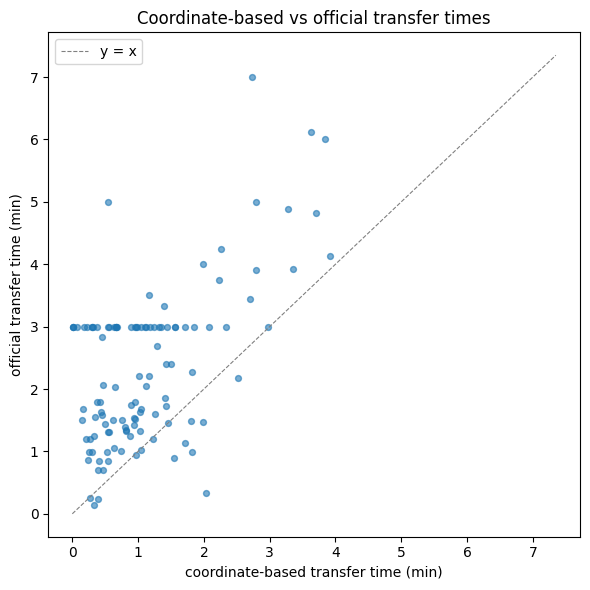


The two correlate (far platforms -> longer transfers), but the coordinate estimate
under-states the official time: straight-line platform distance ignores stairs,
corridors and waiting. Swapping in `official_transfer` would be a one-line change.


In [11]:
import matplotlib.pyplot as plt

# Collect (coordinate time, official time) for shared interchanges.
coord_t, official_t = [], []
lines_at = defaultdict(set)
for (station, line) in node_coords:
    lines_at[station].add(line)
for station, lines in lines_at.items():
    lines = sorted(lines)
    for i in range(len(lines)):
        for j in range(i + 1, len(lines)):
            na, nb = (station, lines[i]), (station, lines[j])
            key = (station, frozenset((lines[i], lines[j])))
            if key in official_transfer:
                coord_t.append(transfer_minutes(na, nb, node_coords, WALKING_SPEED_KMH))
                official_t.append(official_transfer[key])

import statistics
print("Interchanges compared      :", len(coord_t))
print("Mean coordinate-based time : %.2f min" % statistics.mean(coord_t))
print("Mean official time         : %.2f min" % statistics.mean(official_t))
print("Mean absolute difference   : %.2f min" % statistics.mean(
    abs(c - o) for c, o in zip(coord_t, official_t)))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(coord_t, official_t, s=18, alpha=0.6)
lim = max(max(coord_t), max(official_t)) * 1.05
ax.plot([0, lim], [0, lim], color="grey", linestyle="--", linewidth=0.8, label="y = x")
ax.set_xlabel("coordinate-based transfer time (min)")
ax.set_ylabel("official transfer time (min)")
ax.set_title("Coordinate-based vs official transfer times")
ax.legend()
plt.tight_layout()
plt.show()
print("\nThe two correlate (far platforms -> longer transfers), but the coordinate estimate")
print("under-states the official time: straight-line platform distance ignores stairs,")
print("corridors and waiting. Swapping in `official_transfer` would be a one-line change.")

## Part 4 — Querying & itineraries

The user asks for a route *station to station* and should not have to name a line. For each
query we add two temporary nodes:

* `SOURCE`, joined with cost 0 to every `(source_station, line)` node;
* `TARGET`, reached with cost 0 from every `(target_station, line)` node.

The planner then picks the best line to board and alight on. Because the hubs are temporary
and only touch the endpoints, any line change in the middle still pays a transfer edge. The
same function returns the admissible A\* heuristic (Part 1.3) for this target.

In [12]:
SOURCE = "__SOURCE__"
TARGET = "__TARGET__"


def build_query_graph(graph, station_coords, src_station, tgt_station,
                      max_speed_kmh=DEFAULT_MAX_SPEED_KMH):
    """Add temporary boarding/alighting hubs for a single query.

    Returns (query_graph, heuristic). The heuristic h(node) = straight-line distance from
    the node's station to the target station, divided by max_speed; admissible (and
    consistent) when max_speed >= the network's peak effective speed.
    """
    qg = {u: list(neighbours) for u, neighbours in graph.items()}  # shallow copy

    src_nodes = [n for n in graph if isinstance(n, tuple) and n[0] == src_station]
    tgt_nodes = [n for n in graph if isinstance(n, tuple) and n[0] == tgt_station]
    if not src_nodes:
        raise KeyError("Unknown station: %r" % src_station)
    if not tgt_nodes:
        raise KeyError("Unknown station: %r" % tgt_station)

    qg[SOURCE] = [(n, 0.0) for n in src_nodes]
    qg[TARGET] = []
    for n in tgt_nodes:
        qg[n] = qg[n] + [(TARGET, 0.0)]

    tgt_lon, tgt_lat = station_coords[tgt_station]

    def heuristic(node):
        if node == TARGET:
            return 0.0
        station = src_station if node == SOURCE else node[0]
        lon, lat = station_coords[station]
        return km_to_minutes(great_circle_km(lon, lat, tgt_lon, tgt_lat), max_speed_kmh)

    return qg, heuristic


def line_sequence(path):
    """The lines used along a path of (station, line) nodes, without repeats."""
    lines = []
    for node in path:
        if isinstance(node, tuple):
            line = node[1]
            if not lines or lines[-1] != line:
                lines.append(line)
    return lines


def plan(graph, station_coords, src_station, tgt_station,
         algorithm="dijkstra", max_speed_kmh=DEFAULT_MAX_SPEED_KMH):
    """Plan a station-to-station itinerary (the cli/glue layer).

    Returns (path, cost, nodes_expanded); `path` is the (station, line) nodes with the
    SOURCE/TARGET hubs stripped out.
    """
    qg, heuristic = build_query_graph(graph, station_coords,
                                      src_station, tgt_station, max_speed_kmh)
    if algorithm == "dijkstra":
        path, cost, expanded = dijkstra(qg, SOURCE, TARGET)
    elif algorithm == "astar":
        path, cost, expanded = a_star(qg, SOURCE, TARGET, heuristic)
    else:
        raise ValueError("algorithm must be 'dijkstra' or 'astar'")
    inner = [n for n in path if isinstance(n, tuple)]
    return inner, cost, expanded


def describe_itinerary(path, cost):
    """Print an itinerary as board / change / arrive steps."""
    if not path:
        print("No route found.")
        return
    lines = line_sequence(path)
    print("%s -> %s : %.0f min, %d stops, %d line(s) %s"
          % (path[0][0], path[-1][0], cost, len(path), len(lines), lines))
    current_line = None
    for station, line in path:
        if line != current_line:
            verb = "Board     " if current_line is None else "Change to "
            print("  %s line %-3s at %s" % (verb, line, station))
            current_line = line
    print("  Arrive     at %s" % path[-1][0])

### 4.1 Itineraries on the real network

A few representative trips: a long single-line ride, the length of line 4, and a short
trip needing a transfer. Times are real scheduled in-vehicle times plus transfers.

In [13]:
examples = [
    ("La Défense (Grande Arche)", "Château de Vincennes"),
    ("Bagneux - Lucie Aubrac", "Porte de Clignancourt"),
    ("Saint-Lazare", "Nation"),
]
for src, tgt in examples:
    path, cost, _ = plan(metro_graph, station_coords, src, tgt, "dijkstra")
    describe_itinerary(path, cost)
    print()

La Défense (Grande Arche) -> Château de Vincennes : 36 min, 25 stops, 1 line(s) ['1']
  Board      line 1   at La Défense (Grande Arche)
  Arrive     at Château de Vincennes

Bagneux - Lucie Aubrac -> Porte de Clignancourt : 35 min, 29 stops, 1 line(s) ['4']
  Board      line 4   at Bagneux - Lucie Aubrac
  Arrive     at Porte de Clignancourt

Saint-Lazare -> Nation : 14 min, 8 stops, 2 line(s) ['14', '1']
  Board      line 14  at Saint-Lazare
  Change to  line 1   at Gare de Lyon
  Arrive     at Nation



### 4.2 Dijkstra vs A\* return the same optimum

A\* with an admissible heuristic must return the **same cost** as Dijkstra, expanding fewer
nodes. We check both on the example trips.

In [14]:
print("%-28s %-24s %6s %9s %9s" % ("from", "to", "min", "Dijkstra", "A*"))
print("%-28s %-24s %6s %9s %9s" % ("", "", "", "expanded", "expanded"))
for src, tgt in examples:
    _, c_d, e_d = plan(metro_graph, station_coords, src, tgt, "dijkstra")
    _, c_a, e_a = plan(metro_graph, station_coords, src, tgt, "astar")
    assert abs(c_d - c_a) < 1e-9, "A* must match Dijkstra's optimal cost"
    print("%-28s %-24s %6.0f %9d %9d" % (src[:28], tgt[:24], c_d, e_d, e_a))
print("\nSame cost every time; A* expands fewer nodes by aiming at the target.")

from                         to                          min  Dijkstra        A*
                                                              expanded  expanded
La Défense (Grande Arche)    Château de Vincennes         36       375       286
Bagneux - Lucie Aubrac       Porte de Clignancourt        35       365       304
Saint-Lazare                 Nation                       14       245       124

Same cost every time; A* expands fewer nodes by aiming at the target.


### 4.3 Visualising an itinerary (the `viz` layer)

We draw the whole network faintly (the real adjacencies) and the chosen route on top.
Longitude and latitude are not isotropic, so we correct the aspect ratio by `1/cos(lat)` at
the latitude of Paris (~48.86°).

La Défense (Grande Arche) -> Nation : 30 min, 21 stops, 1 line(s) ['1']
  Board      line 1   at La Défense (Grande Arche)
  Arrive     at Nation


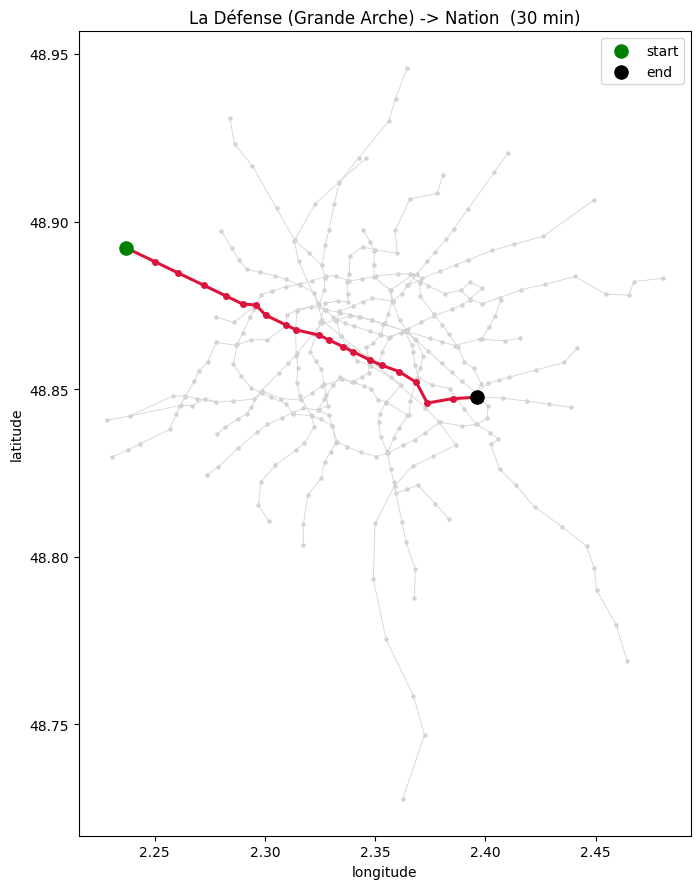

In [15]:
def plot_itinerary(path, node_coords, riding, title=""):
    """Draw the network faintly with the chosen itinerary highlighted."""
    fig, ax = plt.subplots(figsize=(9, 9))

    # All real riding edges, faint.
    for pair in riding:
        a, b = tuple(pair)
        xa, ya = node_coords[a]
        xb, yb = node_coords[b]
        ax.plot([xa, xb], [ya, yb], color="lightgrey", linewidth=0.6, zorder=1)
    xs = [lo for lo, la in node_coords.values()]
    ys = [la for lo, la in node_coords.values()]
    ax.scatter(xs, ys, s=5, color="lightgrey", zorder=1)

    # The itinerary on top.
    px = [node_coords[n][0] for n in path]
    py = [node_coords[n][1] for n in path]
    ax.plot(px, py, color="crimson", linewidth=2.2, zorder=2)
    ax.scatter(px, py, s=16, color="crimson", zorder=3)
    ax.scatter([px[0]], [py[0]], s=90, color="green", zorder=4, label="start")
    ax.scatter([px[-1]], [py[-1]], s=90, color="black", zorder=4, label="end")

    ax.set_aspect(1.0 / math.cos(math.radians(48.86)))
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_title(title)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


src, tgt = "La Défense (Grande Arche)", "Nation"
path, cost, _ = plan(metro_graph, station_coords, src, tgt, "dijkstra")
describe_itinerary(path, cost)
plot_itinerary(path, node_coords, riding, title="%s -> %s  (%.0f min)" % (src, tgt, cost))

## Part 5 — Experiments (trade-offs)

The three experimental questions from the plan, each framed as a trade-off.

### 5.1 Effect of walking speed on the chosen route

Transfer times are data-driven (platform distance / walking speed), so the natural
parameter is the assumed **walking speed** (3, 5, 7, 10 km/h). Faster walking shrinks every
transfer, so the planner is willing to accept more line changes for a shorter ride. We flag
any pair whose line sequence flips.

In [16]:
walking_speeds = [3.0, 5.0, 7.0, 10.0]
pairs = [
    ("La Défense (Grande Arche)", "Château de Vincennes"),
    ("Saint-Lazare", "Nation"),
    ("Pont de Levallois - Bécon", "Gallieni"),
    ("La Courneuve - 8 Mai 1945", "Mairie d'Issy"),
    ("Balard", "Bobigny - Pablo Picasso"),
]

graphs_ws = {ws: build_metro_graph(riding, node_coords, walking_speed=ws)[0]
             for ws in walking_speeds}

print("%-44s" % "OD pair" + "".join("%-18s" % ("walk=%g km/h" % ws) for ws in walking_speeds))
for src, tgt in pairs:
    seqs = []
    for ws in walking_speeds:
        path, _, _ = plan(graphs_ws[ws], station_coords, src, tgt, "dijkstra")
        seqs.append(line_sequence(path))
    label = "%s -> %s" % (src, tgt)
    row = "%-44s" % label[:44] + "".join("%-18s" % str(s) for s in seqs)
    if any(s != seqs[0] for s in seqs):
        row += "<- route changes"
    print(row)
print("\nFaster walking -> cheaper transfers -> the planner accepts more line changes.")

OD pair                                     walk=3 km/h       walk=5 km/h       walk=7 km/h       walk=10 km/h      
La Défense (Grande Arche) -> Château de Vinc['1']             ['1']             ['1', '14', '1']  ['1', '14', '1']  <- route changes
Saint-Lazare -> Nation                      ['14', '1']       ['14', '1']       ['14', '1']       ['14', '1']       
Pont de Levallois - Bécon -> Gallieni       ['3']             ['3', '9', '8', '3']['3', '9', '8', '3']['3', '9', '8', '3']<- route changes
La Courneuve - 8 Mai 1945 -> Mairie d'Issy  ['7', '4', '12']  ['7', '4', '12']  ['7', '4', '12']  ['7', '4', '12']  
Balard -> Bobigny - Pablo Picasso           ['8', '7', '5']   ['8', '7', '7B', '5']['8', '7', '7B', '5']['8', '7', '7B', '5']<- route changes

Faster walking -> cheaper transfers -> the planner accepts more line changes.


### 5.2 Choosing `max_speed` for the heuristic

The heuristic is `h = great_circle / max_speed * 60`. With real travel times, it is a valid
lower bound for *every possible query* iff `max_speed` is at least the **fastest effective
speed any single segment reaches** (`V_peak`): a query along that one segment has exactly
that straight-line speed. We measure `V_peak` from the timetable, then show the trade-off:

* `max_speed < V_peak` -> `h` is no longer guaranteed admissible -> A\* **can return a
  sub-optimal route** (the example pair below does, at 25 km/h);
* `max_speed >= V_peak` -> provably admissible -> always optimal, but a larger `max_speed`
  weakens `h`, so A\* expands more nodes.

Note the *worst-case* threshold `V_peak` is stricter than what a typical query needs: most
trips span many slow hops, so their straight-line speed is low and they stay optimal well
below `V_peak` (the random-pair sweep reaches 100% optimal by ~35 km/h). The principled
choice that guarantees optimality for **all** queries is `max_speed` just above `V_peak`,
which is why we default to 60.

In [17]:
# Measure the peak effective segment speed from the real data.
seg_speeds = sorted(great_circle_km(*node_coords[a], *node_coords[b]) / (t / 60.0)
                    for pair, t in riding.items() for a, b in [tuple(pair)])
V_peak = seg_speeds[-1]
print("Effective segment speed: median %.1f | p95 %.1f | peak (V_peak) %.1f km/h"
      % (seg_speeds[len(seg_speeds) // 2], seg_speeds[int(0.95 * len(seg_speeds))], V_peak))

src, tgt = "Javel - André Citroën", "Bercy"
_, optimal_cost, _ = plan(metro_graph, station_coords, src, tgt, "dijkstra")
speeds = [25, 35, 45, 50, 55, 60, 80, 120]
print("\n%s -> %s : optimal cost = %.0f min\n" % (src, tgt, optimal_cost))
print("%10s %12s %10s %12s" % ("max_speed", "A* expanded", "cost", "optimal?"))
expanded_by_speed = []
for v in speeds:
    _, cost, exp = plan(metro_graph, station_coords, src, tgt, "astar", max_speed_kmh=v)
    expanded_by_speed.append(exp)
    ok = "yes" if abs(cost - optimal_cost) < 1e-9 else "NO (inadmissible)"
    print("%10.0f %12d %10.0f %12s" % (v, exp, cost, ok))

# Optimality over many random pairs, as a function of max_speed.
import random
random.seed(0)
stations = list(station_coords)
test_pairs = [(a, b) for a, b in
              ((random.choice(stations), random.choice(stations)) for _ in range(40)) if a != b]
print("\nFraction of %d random pairs solved optimally:" % len(test_pairs))
for v in speeds:
    optimal = 0
    for a, b in test_pairs:
        _, c_ref, _ = plan(metro_graph, station_coords, a, b, "dijkstra")
        _, c_a, _ = plan(metro_graph, station_coords, a, b, "astar", max_speed_kmh=v)
        if abs(c_a - c_ref) < 1e-9:
            optimal += 1
    print("  max_speed %3.0f km/h : %3.0f%%" % (v, 100.0 * optimal / len(test_pairs)))

Effective segment speed: median 23.1 | p95 37.8 | peak (V_peak) 54.3 km/h

Javel - André Citroën -> Bercy : optimal cost = 21 min

 max_speed  A* expanded       cost     optimal?
        25           71         24 NO (inadmissible)
        35           96         21          yes
        45          111         21          yes
        50          123         21          yes
        55          133         21          yes
        60          142         21          yes
        80          161         21          yes
       120          180         21          yes

Fraction of 40 random pairs solved optimally:
  max_speed  25 km/h :  98%
  max_speed  35 km/h : 100%
  max_speed  45 km/h : 100%
  max_speed  50 km/h : 100%
  max_speed  55 km/h : 100%


  max_speed  60 km/h : 100%


  max_speed  80 km/h : 100%
  max_speed 120 km/h : 100%


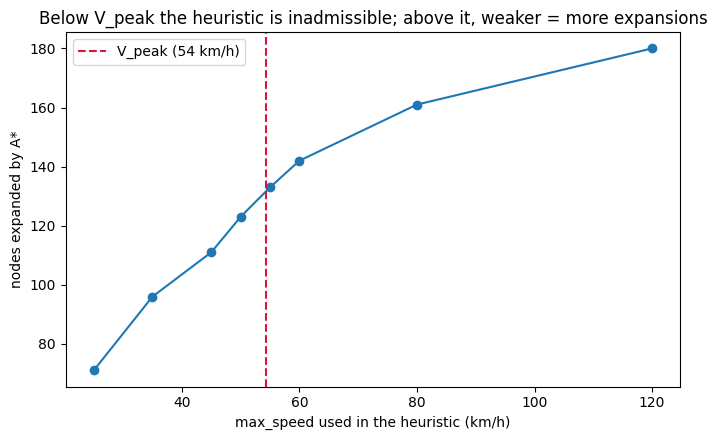

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(speeds, expanded_by_speed, marker="o")
ax.axvline(V_peak, color="crimson", linestyle="--", label="V_peak (%.0f km/h)" % V_peak)
ax.set_xlabel("max_speed used in the heuristic (km/h)")
ax.set_ylabel("nodes expanded by A*")
ax.set_title("Below V_peak the heuristic is inadmissible; above it, weaker = more expansions")
ax.legend()
plt.tight_layout()
plt.show()

### 5.3 When does A\* beat Dijkstra?

A\* helps most when the straight-line distance is a good guide, i.e. for **distant** pairs.
We sample many random pairs, measure the ratio of nodes expanded (Dijkstra / A\*), and plot
it against the great-circle distance between the endpoints.

Pairs sampled        : 150
Median speed-up (Dijkstra expanded / A* expanded) : 1.49x


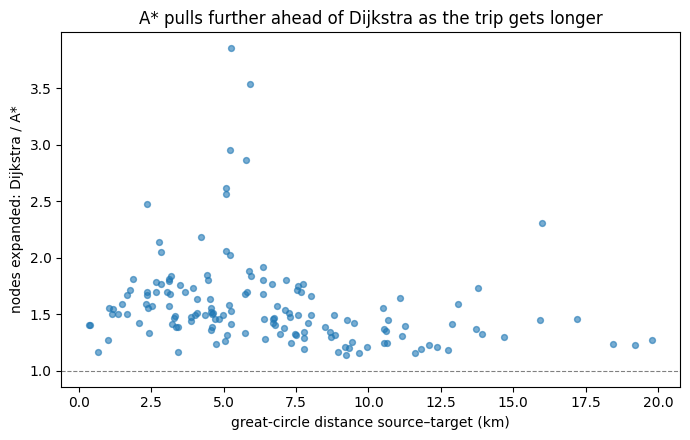

In [19]:
random.seed(1)
samples = []
for _ in range(150):
    a, b = random.choice(stations), random.choice(stations)
    if a == b:
        continue
    _, _, e_d = plan(metro_graph, station_coords, a, b, "dijkstra")
    _, _, e_a = plan(metro_graph, station_coords, a, b, "astar")
    lon1, lat1 = station_coords[a]
    lon2, lat2 = station_coords[b]
    samples.append((great_circle_km(lon1, lat1, lon2, lat2), e_d / max(e_a, 1)))

dists = [d for d, _ in samples]
ratios = [r for _, r in samples]
print("Pairs sampled        :", len(samples))
print("Median speed-up (Dijkstra expanded / A* expanded) : %.2fx" % sorted(ratios)[len(ratios) // 2])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(dists, ratios, s=18, alpha=0.6)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("great-circle distance source–target (km)")
ax.set_ylabel("nodes expanded: Dijkstra / A*")
ax.set_title("A* pulls further ahead of Dijkstra as the trip gets longer")
plt.tight_layout()
plt.show()

## Part 6 — Course tie-ins & extensions

How each course topic shows up: **BFS** verified one connected component (Part 3.1);
**Dijkstra** is the workhorse; **A\*** is the advanced shortest path; **MST** gives a
sanity-check skeleton (below); **topological sort** applies to the time-expanded graph
(Part 6.3).

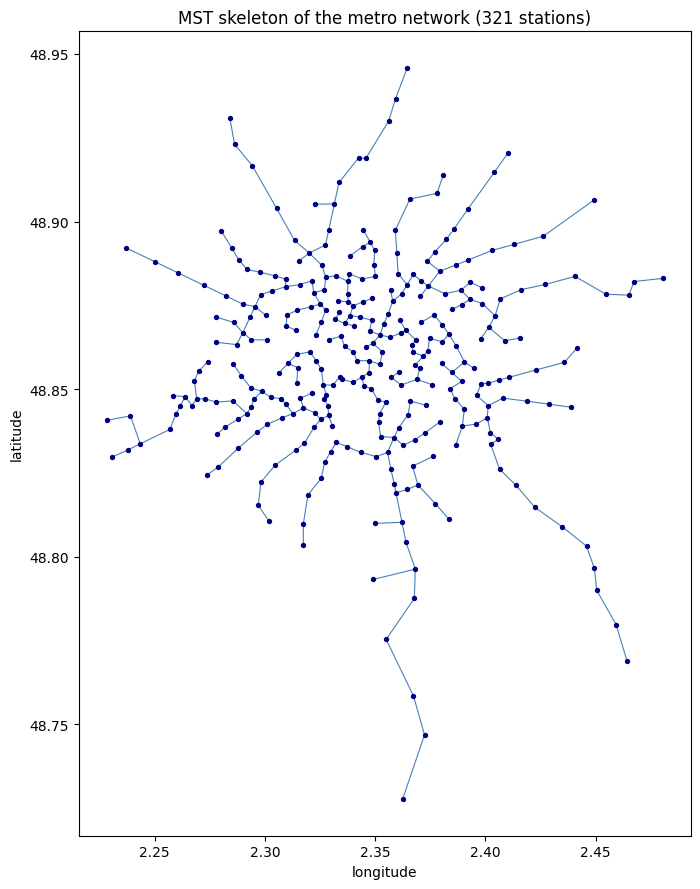

In [20]:
def prim_mst(points):
    """Minimum spanning tree of `points` under great-circle distance (plain Prim).

    `points`: list of (label, lon, lat). Returns edges as (i, j, distance_km).
    """
    n = len(points)
    if n <= 1:
        return []
    in_tree = [False] * n
    in_tree[0] = True
    edges = []
    pq = []
    for j in range(1, n):
        heapq.heappush(pq, (great_circle_km(points[0][1], points[0][2],
                                            points[j][1], points[j][2]), 0, j))
    while pq and len(edges) < n - 1:
        d, i, j = heapq.heappop(pq)
        if in_tree[j]:
            continue
        in_tree[j] = True
        edges.append((i, j, d))
        for k in range(n):
            if not in_tree[k]:
                heapq.heappush(pq, (great_circle_km(points[j][1], points[j][2],
                                                    points[k][1], points[k][2]), j, k))
    return edges


# MST skeleton of the whole network (pure geometry, ignoring lines) — a sanity figure.
all_points = [(name, lon, lat) for name, (lon, lat) in station_coords.items()]
skeleton = prim_mst(all_points)

fig, ax = plt.subplots(figsize=(9, 9))
for i, j, _ in skeleton:
    ax.plot([all_points[i][1], all_points[j][1]],
            [all_points[i][2], all_points[j][2]], color="steelblue", linewidth=0.8, zorder=1)
ax.scatter([p[1] for p in all_points], [p[2] for p in all_points], s=8, color="navy", zorder=2)
ax.set_aspect(1.0 / math.cos(math.radians(48.86)))
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("MST skeleton of the metro network (%d stations)" % len(all_points))
plt.tight_layout()
plt.show()

### 6.1 Returning the second-best path (oral prep)

The review notes we may be asked to *modify Dijkstra to return the second-best path*. A
simple, robust method: take the optimal path, remove each of its edges in turn, re-run
Dijkstra, and keep the cheapest route that differs from the optimum. This reuses `dijkstra`
unchanged.

In [21]:
def second_best_path(graph, source, target):
    """Cheapest source->target path differing from the optimal one by >= 1 edge."""
    base_path, base_cost, _ = dijkstra(graph, source, target)
    if len(base_path) < 2:
        return [], float("inf")

    best_path, best_cost = [], float("inf")
    for u, v in zip(base_path, base_path[1:]):
        pruned = {
            n: [(w, c) for (w, c) in nbrs
                if not ((n == u and w == v) or (n == v and w == u))]
            for n, nbrs in graph.items()
        }
        path, cost, _ = dijkstra(pruned, source, target)
        if path and path != base_path and cost < best_cost:
            best_path, best_cost = path, cost
    return best_path, best_cost


def plan_second_best(graph, station_coords, src_station, tgt_station):
    qg, _ = build_query_graph(graph, station_coords, src_station, tgt_station)
    path, cost = second_best_path(qg, SOURCE, TARGET)
    return [n for n in path if isinstance(n, tuple)], cost


src, tgt = "La Défense (Grande Arche)", "Château de Vincennes"
best_path, best_cost, _ = plan(metro_graph, station_coords, src, tgt, "dijkstra")
alt_path, alt_cost = plan_second_best(metro_graph, station_coords, src, tgt)

print("%s -> %s" % (src, tgt))
print("  best        : %.0f min, lines %s" % (best_cost, line_sequence(best_path)))
if alt_path:
    print("  second best : %.0f min, lines %s" % (alt_cost, line_sequence(alt_path)))
else:
    print("  second best : none (the optimal route is the only one)")

La Défense (Grande Arche) -> Château de Vincennes
  best        : 36 min, lines ['1']
  second best : 36 min, lines ['1', '14', '1']


### 6.2 Complexity & guarantees

* **Dijkstra** with a binary heap is `O((V + E) log V)`: each node is popped once and each
  edge can trigger one push, every heap operation costing `O(log V)`. A **Fibonacci heap**
  gives `O(E + V log V)` in theory, but its constants make the binary heap faster on graphs
  this size, so we keep `heapq`.
* **A\*** keeps Dijkstra's optimality with an admissible heuristic and avoids re-expansion
  with a consistent one. The heuristic changes only the *order* of expansion, never the
  optimum.
* **Bidirectional Dijkstra** (not implemented) searches from both ends. The subtle part is
  the stopping rule: it is **not** "the searches meet". A correct condition is to stop once
  the sum of the two frontiers' minimum keys exceeds the best full path found so far through
  any scanned node, then take that best meeting node. Getting this wrong silently returns
  sub-optimal paths, which is why we flag it rather than rush it.

### 6.3 Topological sort & the time-expanded graph

Our route-space graph is undirected, so topological sort does not apply to it directly. It
*does* apply to the natural next model for real timetables: a **time-expanded graph** with
one node per `(stop, line, departure_time)` and directed edges that always move forward in
time (ride to the next departure, or wait for a later one). Because every edge increases
time, the graph is a **DAG**, and a topological order (by time) is the natural traversal —
the best route at 7am can then differ from the one at 11pm. We already have the departure
times in `stop_times.txt`, so this is the main avenue for extending the planner.

### 6.4 Limitations & what is still approximate

* **Schedule, not real-time.** Edge weights are mean scheduled times, with no service
  disruptions and no time-of-day variation (the time-expanded graph in 6.3 would fix the
  latter).
* **Transfer times** are straight-line platform distance / walking speed. This correlates
  with the official `transfers.txt` (Part 3.2) but under-states it, because it ignores
  stairs, corridors and waiting. Using `official_transfer` directly is a one-line change.
* **Metro only.** Adding RER (`route_type` 2) or bus (3) is purely a parser change — the
  graph, both solvers and the maps are mode-agnostic. Note that the admissible `max_speed`
  would then have to rise to the fastest mode (RER is much faster than the metro).
* **Geographic distance drives the heuristic**, which is exactly why it stays an admissible
  lower bound on travel time.

Every limitation above is confined to the parser: the `(station, line)` graph, Dijkstra,
A\* and the visualisation would not change.